# 📘 Notebook 01 — Chuẩn bị dữ liệu & Phân tích khám phá (EDA)

**Đề tài:** *Bộ thủ và cấu trúc chữ chồng chữ trong chữ Hán từ góc nhìn của người Việt: Đặc điểm, giá trị văn hóa và ứng dụng trong dạy học*

**Vai trò của notebook này trong pipeline 4-phần:**

| Notebook | Nội dung | Câu hỏi nghiên cứu |
|:--:|:--|:--|
| **01 (notebook này)** | **Chuẩn bị dữ liệu, EDA, mô tả mẫu** | Ai là đối tượng khảo sát? Chất lượng dữ liệu ra sao? |
| 02 | Phân tích định lượng: độ tin cậy, kiểm định mối liên hệ, so sánh nhóm | RQ1, RQ3 |
| 03 | Phân tích định tính: multi-select, nhận diện nghĩa chữ, thematic Q60 | RQ2, RQ3 |
| 04 | Phân tích nâng cao: EFA, Ordinal Logit, CA, Cluster, IRT | RQ2, RQ4 |

**Mẫu khảo sát:** N = 548 người Việt đang học tiếng Trung  
**Bảng hỏi:** 59 câu hỏi, chia thành 6 phần (S1–S6)

## 0. Cấu hình môi trường

Các gói cần thiết (cài đặt một lần nếu chưa có):

```bash
pip install pandas numpy matplotlib seaborn scipy scikit-learn \
    statsmodels pingouin factor_analyzer wordcloud openpyxl pyarrow \
    prince kmodes
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị — font DejaVu hỗ trợ tiếng Việt và Noto CJK cho chữ Hán
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'Noto Sans CJK SC']
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.05)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('✅ Môi trường sẵn sàng')

✅ Môi trường sẵn sàng


## 1. Đọc dữ liệu từ 3 sheet của Excel

File `Data.xlsx` có 3 sheet:
- **Data**: 548 phản hồi × 59 câu hỏi (dữ liệu thô)
- **Questions**: metadata mỗi câu (ID, Section, DataAnswerType, QuestionType, Question)
- **Sections**: mô tả 8 phần (S1–S6)

Chúng ta dùng module `prep_data.py` đã được kiểm định kỹ để chuẩn hoá toàn bộ dữ liệu Likert.

In [2]:
# Import module chuẩn bị dữ liệu (phải đặt file prep_data.py cùng thư mục với notebook)
from prep_data import load_and_prepare, CORRECT_ANSWERS, ORDERS, MULTI_COLS, CONSTRUCTS

# Đổi đường dẫn nếu cần
DATA_PATH = 'Data.xlsx'
df, questions, sections, META = load_and_prepare(DATA_PATH)

print(f'Dữ liệu thô       : {df.shape[0]} phản hồi × 59 câu hỏi gốc')
print(f'Sau xử lý         : {df.shape[1]} cột (gồm cả biến số hoá & list multi-select)')
print(f'Tỉ lệ missing tổng: {df.isnull().mean().mean():.2%}')

Dữ liệu thô       : 548 phản hồi × 59 câu hỏi gốc
Sau xử lý         : 122 cột (gồm cả biến số hoá & list multi-select)
Tỉ lệ missing tổng: 0.44%


In [3]:
# Xem 3 dòng đầu của các cột chính
cols_preview = ['Q1', 'Q4', 'Q8', 'Q44', 'Q46', 'HV_score', 'SEM_score']
df[cols_preview].head(3)

,Q1,Q4,Q8,Q44,Q46,HV_score,SEM_score
0,23 – 30,Mới bắt đầu,Quan trọng,Khá thích,Khá mong muốn,5.00,8
1,Trên 30,HSK1 – HSK2,Quan trọng,Bình thường,Khá mong muốn,4.50,6
2,23 – 30,HSK1 – HSK2,Rất quan trọng,Khá thích,Khá mong muốn,4.25,8


## 2. Mô tả 8 phần khảo sát (Sections)

In [4]:
# Đếm câu hỏi trong mỗi phần + ghép với mô tả
sec_summary = (questions.groupby('Section').size()
                        .rename('Số câu hỏi').reset_index()
                        .merge(sections, on='Section'))
sec_summary = sec_summary[['Section', 'Description', 'Số câu hỏi']]
sec_summary

,Section,Description,Số câu hỏi
0,S1,THÔNG TIN NGƯỜI THAM GIA,5
1,S2,NHẬN THỨC VỀ BỘ THỦ TRONG CHỮ HÁN,16
2,S3,NHẬN THỨC VỀ CẤU TRÚC CHỮ CHỒNG CHỮ TRONG CHỮ HÁN,9
3,S4.1,THỬ THÁCH NHẬN BIẾT VÀ SUY LUẬN CHỮ HÁN - PHẦN NHẬN BIẾT,3
4,S4.2,THỬ THÁCH NHẬN BIẾT VÀ SUY LUẬN CHỮ HÁN - PHẦN ĐOÁN CHỮ,8
5,S4.3,THỬ THÁCH NHẬN BIẾT VÀ SUY LUẬN CHỮ HÁN - PHẦN TƯ DUY,5
6,S5,CẢM NHẬN VÀ ĐỀ XUẤT CỦA NGƯỜI HỌC VỀ CẤU TRÚC CHỮ HÁN,12
7,S6,CÂU HỎI MỞ,1


## 3. Metadata câu hỏi (Questions sheet)

Danh sách 59 câu hỏi với loại dữ liệu:

In [5]:
print(f'Tổng câu hỏi: {len(questions)}')
print(f'\nPhân bố theo loại dữ liệu:')
print(questions['DataAnswerType'].value_counts().to_string())
print(f'\nPhân bố theo loại câu trả lời:')
print(questions['QuestionType'].value_counts().to_string())

Tổng câu hỏi: 59

Phân bố theo loại dữ liệu:
DataAnswerType
Categorical    30
LIKERT-5       27
Binary          1
Text            1

Phân bố theo loại câu trả lời:
QuestionType
Chọn 1 đáp án               50
Chọn nhiều đáp án            8
Định tính, trả lời tự do     1


In [6]:
# Bảng metadata đầy đủ
questions

,ID,Section,DataAnswerType,QuestionType,Question
0,Q1,S1,Categorical,Chọn 1 đáp án,Câu 1. Độ tuổi của bạn?
1,Q2,S1,Categorical,Chọn 1 đáp án,Câu 2: Bạn thuộc nhóm người học tiếng Trung nào sau đây?
2,Q3,S1,Categorical,Chọn 1 đáp án,Câu 3: Bạn đã học tiếng Trung trong bao lâu?
3,Q4,S1,Categorical,Chọn 1 đáp án,Câu 4: Trình độ tiếng Trung của bạn (Tự đánh giá)
4,Q5,S1,Categorical,Chọn 1 đáp án,Câu 5. Mục đích chính (quan trọng nhất) của bạn khi học tiếng Trung là gì?
5,Q6,S2,Binary,Chọn 1 đáp án,Câu 1. Bạn có biết chữ Hán được cấu tạo từ các bộ thủ không?
6,Q7,S2,LIKERT-5,Chọn 1 đáp án,"Câu 2. Khi học chữ Hán, bạn chú ý đến bộ thủ ở mức độ nào?"
7,Q8,S2,Categorical,Chọn 1 đáp án,Câu 3. Bạn cảm thấy học bộ thủ có quan trọng không?
8,Q9,S2,Categorical,Chọn nhiều đáp án,"Câu 4. Theo bạn, bộ thủ giúp ích gì khi học chữ Hán? (Có thể chọn nhiều đáp án)"
9,Q10,S2,Categorical,Chọn 1 đáp án,Câu 5. Bạn có biết trong chữ Hán có khoảng bao nhiêu bộ thủ không?


## 4. Mô tả mẫu khảo sát (N = 548)

### 4.1 Các biến nhân khẩu học cơ bản

In [7]:
def describe_var(col, title, order=None):
    vc = df[col].value_counts(dropna=False)
    if order is not None:
        vc = vc.reindex([o for o in order if o in vc.index])
    tbl = pd.DataFrame({'N': vc, '%': (vc / len(df) * 100).round(1)})
    tbl.index.name = title
    return tbl

print('BẢNG 1A. Độ tuổi (Q1)')
print('=' * 50)
print(describe_var('Q1', 'Độ tuổi', ORDERS['Q1']).to_string())

print('\nBẢNG 1B. Thời gian học tiếng Trung (Q3)')
print('=' * 50)
print(describe_var('Q3', 'Thời gian học', ORDERS['Q3']).to_string())

print('\nBẢNG 1C. Trình độ tiếng Trung (Q4)')
print('=' * 50)
print(describe_var('Q4', 'Trình độ HSK', ORDERS['Q4']).to_string())

BẢNG 1A. Độ tuổi (Q1)
           N     %
Độ tuổi           
Dưới 18   14   2.6
18 – 22  238  43.4
23 – 30  146  26.6
Trên 30  150  27.4

BẢNG 1B. Thời gian học tiếng Trung (Q3)
                   N     %
Thời gian học             
Dưới 6 tháng     219  40.0
6 tháng – 1 năm  127  23.2
1 – 3 năm        131  23.9
Trên 3 năm        71  13.0

BẢNG 1C. Trình độ tiếng Trung (Q4)
                N     %
Trình độ HSK           
Mới bắt đầu   171  31.2
HSK1 – HSK2   174  31.8
HSK3 – HSK4   134  24.5
HSK5 - HSK6    57  10.4
HSK6 trở lên   12   2.2


In [8]:
# Mục đích học
print('BẢNG 1D. Mục đích học tiếng Trung (Q5)')
print('=' * 60)
print(describe_var('Q5', 'Mục đích').to_string())

BẢNG 1D. Mục đích học tiếng Trung (Q5)
                                                       N     %
Mục đích                                                      
Học tập                                              252  46.0
Công việc                                            141  25.7
Sở thích                                             113  20.6
Nghiên cứu                                            32   5.8
Học tập và đi du học                                   1   0.2
Nghe nói đọc viết được,  Giao tiếp được tiếng trung    1   0.2
Yêu thích                                              1   0.2
Trường dạy                                             1   0.2
Học tập, công việc, sở thích                           1   0.2
Du lịch                                                1   0.2
Rảnh quá không biết làm gì                             1   0.2
Đi dạy                                                 1   0.2
Du học                                                 1   0.2
Kiếm tiền       

### 4.2 Hình 1 — Trực quan hoá đặc điểm nhân khẩu học

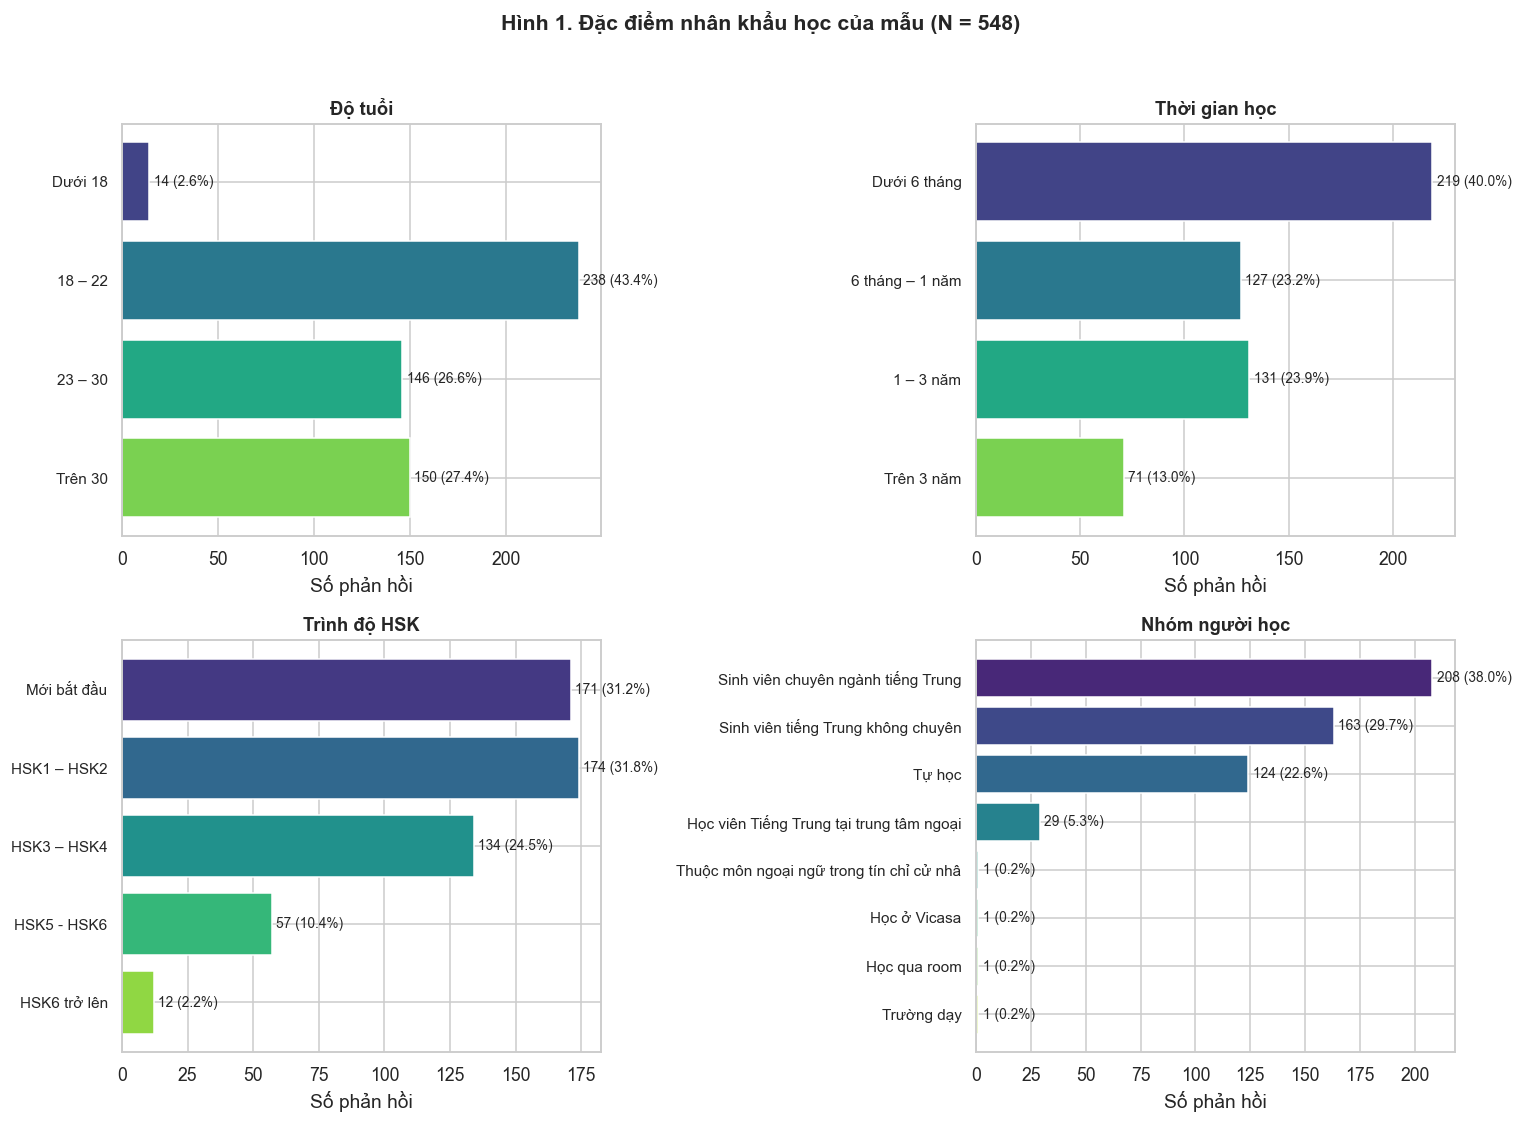

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
demos = [
    ('Q1', 'Độ tuổi',          ORDERS['Q1']),
    ('Q3', 'Thời gian học',    ORDERS['Q3']),
    ('Q4', 'Trình độ HSK',     ORDERS['Q4']),
    ('Q2', 'Nhóm người học',   None),
]
for ax, (col, label, order) in zip(axes.flatten(), demos):
    vc = df[col].value_counts()
    if order is not None:
        vc = vc.reindex([o for o in order if o in vc.index])
    else:
        vc = vc.head(8)
    colors = sns.color_palette('viridis', len(vc))
    bars = ax.barh(range(len(vc)), vc.values, color=colors)
    ax.set_yticks(range(len(vc)))
    ax.set_yticklabels([str(x)[:40] for x in vc.index], fontsize=10)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('Số phản hồi')
    ax.invert_yaxis()
    for i, v in enumerate(vc.values):
        ax.text(v + max(vc.values)*0.01, i, f'{v} ({v/len(df)*100:.1f}%)',
                va='center', fontsize=9)

plt.suptitle(f'Hình 1. Đặc điểm nhân khẩu học của mẫu (N = {len(df)})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig01_demographics.png', dpi=300)
plt.show()

## 5. Chất lượng dữ liệu

### 5.1 Missing values theo từng cột

In [10]:
# Tỉ lệ missing theo cột gốc (59 câu hỏi)
orig_cols = questions['ID'].tolist()
miss = df[orig_cols].isnull().mean().sort_values(ascending=False)
miss_df = pd.DataFrame({'ID': miss.index, 'Missing %': (miss.values*100).round(2)})
miss_df = miss_df.merge(questions[['ID', 'Section']], on='ID')
miss_df = miss_df[miss_df['Missing %'] > 0]
print(f'Tổng cột có missing: {len(miss_df)}/{len(orig_cols)}')
if len(miss_df) > 0:
    print(miss_df.to_string(index=False))
else:
    print('Không có missing nào.')

Tổng cột có missing: 1/59
 ID  Missing % Section
Q60      51.28      S6


### 5.2 Ghi chú về Q60 (câu mở) và Q50 (ma trận Likert)

- **Q60** (câu hỏi mở, tự do trả lời) có tỉ lệ bỏ trống cao — đây là điều bình thường vì câu hỏi không bắt buộc.
- **Q50_1 đến Q50_5** là thang ma trận (matrix Likert) đánh giá cảm nhận sau khi hoàn thành khảo sát. Sẽ được phân tích kỹ trong notebook 04 (EFA).

## 6. Mã hoá biến Likert

Module `prep_data.py` đã chuyển đổi **32 biến Likert** từ chuỗi tiếng Việt sang thang số 1–5. Các thang được phân loại như sau:

In [11]:
# Tổng quan các thang đo
scales_info = {
    'Thang Frequency (1=Không bao giờ → 5=Luôn luôn)':
        ['Q7_num', 'Q14_num', 'Q15_num', 'Q16_num', 'Q18_num', 'Q27_num'],
    'Thang Agreement (1=Hoàn toàn không đồng ý → 5=Hoàn toàn đồng ý)':
        ['Q13_1_num', 'Q13_2_num', 'Q13_3_num', 'Q13_4_num',
         'Q45_num', 'Q49_num', 'Q50_1_num', 'Q50_2_num', 'Q50_3_num', 'Q50_4_num'],
    'Thang Agreement REVERSE (tuyên bố tiêu cực)':
        ['Q13_5_num', 'Q50_5_num'],
    'Thang Importance (1=Không quan trọng → 5=Rất quan trọng)':
        ['Q8_num'],
    'Thang Necessity (1=Không cần thiết → 5=Cực kỳ cần thiết)':
        ['Q24_num', 'Q47_num'],
    'Thang Desire (1=Không mong muốn → 5=Rất mong muốn)':
        ['Q46_num'],
    'Thang Like (1=Không thích → 5=Rất thích)':
        ['Q44_num'],
    'Thang Effectiveness (1=Không hiệu quả → 5=Rất hiệu quả)':
        ['Q40_num'],
    'Thang Knowledge (1=Chưa từng nghe → 4=Đã tìm hiểu kỹ)':
        ['Q17_num'],
    'Thang đặc thù (Q20/Q23/Q28/Q29)':
        ['Q20_num', 'Q23_num', 'Q28_num', 'Q29_num'],
}

for scale, cols in scales_info.items():
    print(f'\n{scale}:')
    for c in cols:
        if c in df.columns:
            m, sd, n = df[c].mean(), df[c].std(), df[c].notna().sum()
            print(f'   {c:12s}: M={m:.2f}, SD={sd:.2f}, n={n}')


Thang Frequency (1=Không bao giờ → 5=Luôn luôn):
   Q7_num      : M=3.58, SD=0.87, n=548
   Q14_num     : M=3.24, SD=1.01, n=548
   Q15_num     : M=3.12, SD=0.95, n=548
   Q16_num     : M=3.08, SD=1.12, n=548
   Q18_num     : M=3.78, SD=0.84, n=548
   Q27_num     : M=3.93, SD=0.85, n=548

Thang Agreement (1=Hoàn toàn không đồng ý → 5=Hoàn toàn đồng ý):
   Q13_1_num   : M=4.17, SD=1.02, n=548
   Q13_2_num   : M=4.08, SD=1.02, n=548
   Q13_3_num   : M=4.13, SD=0.99, n=548
   Q13_4_num   : M=4.12, SD=0.97, n=548
   Q45_num     : M=3.20, SD=1.28, n=548
   Q49_num     : M=4.08, SD=0.77, n=548
   Q50_1_num   : M=3.21, SD=1.30, n=548
   Q50_2_num   : M=3.22, SD=1.28, n=548
   Q50_3_num   : M=3.23, SD=1.29, n=548
   Q50_4_num   : M=3.25, SD=1.33, n=548

Thang Agreement REVERSE (tuyên bố tiêu cực):
   Q13_5_num   : M=2.77, SD=1.19, n=548
   Q50_5_num   : M=3.21, SD=1.23, n=548

Thang Importance (1=Không quan trọng → 5=Rất quan trọng):
   Q8_num      : M=4.19, SD=0.87, n=548

Thang Necessity (1

### 6.1 Ghi chú đảo ngược (reverse coding)

Hai câu hỏi được đảo ngược vì chúng phát biểu **tiêu cực**:
- **Q13_5** — *"Học bộ thủ khá khô khan, phức tạp, khó nhớ"* → đồng ý CAO = thái độ TIÊU CỰC → đảo ngược cho nhất quán với Q13_1–Q13_4
- **Q50_5** — *"Tôi không nhận thấy sự khác biệt rõ ràng so với các chữ Hán khác"* → tương tự

## 7. Điểm tổng hợp (Composite scores)

Ba điểm tổng hợp được tính từ các nhóm câu hỏi đo cùng một khái niệm:

In [12]:
# Hiển thị định nghĩa và thống kê mô tả
composite_info = [
    ('HV_score', 'Nhận thức về lợi thế Hán–Việt',
     ['Q13_1', 'Q13_2', 'Q13_3', 'Q13_4'],
     'Bộ thủ giúp ghi nhớ / đoán nghĩa / hiểu cấu trúc / cần GV giải thích'),
    ('POST_score', 'Thái độ sau khi làm khảo sát',
     ['Q50_1', 'Q50_2', 'Q50_3', 'Q50_4'],
     'Thú vị / dễ nhớ / rõ nghĩa / phản ánh tư duy trực quan'),
    ('PRACTICE_score', 'Thực hành học bộ thủ',
     ['Q14', 'Q15', 'Q16', 'Q27'],
     'Học theo nhóm / nhầm lẫn / tra cứu / liên hệ HV'),
    ('SEM_score', 'Điểm nhận diện nghĩa chữ chồng chữ (0–8)',
     ['Q30', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37'],
     '淼 休 忍 炎 品 众 双 囍'),
]

print(f'{"Biến":<18}{"N":>5}{"Mean":>8}{"SD":>7}{"Min":>6}{"Max":>6}  Ý nghĩa')
print('=' * 110)
for var, label, items, desc in composite_info:
    s = df[var].dropna()
    print(f'{var:<18}{len(s):>5}{s.mean():>8.2f}{s.std():>7.2f}{s.min():>6.2f}{s.max():>6.2f}  {label}')
    print(f'{" " * 50} Items: {"+".join(items)}')

Biến                  N    Mean     SD   Min   Max  Ý nghĩa
HV_score            548    4.12   0.91  1.00  5.00  Nhận thức về lợi thế Hán–Việt
                                                   Items: Q13_1+Q13_2+Q13_3+Q13_4
POST_score          548    3.23   1.24  1.00  5.00  Thái độ sau khi làm khảo sát
                                                   Items: Q50_1+Q50_2+Q50_3+Q50_4
PRACTICE_score      548    3.34   0.56  1.75  5.00  Thực hành học bộ thủ
                                                   Items: Q14+Q15+Q16+Q27
SEM_score           548    5.86   2.15  0.00  8.00  Điểm nhận diện nghĩa chữ chồng chữ (0–8)
                                                   Items: Q30+Q31+Q32+Q33+Q34+Q35+Q36+Q37


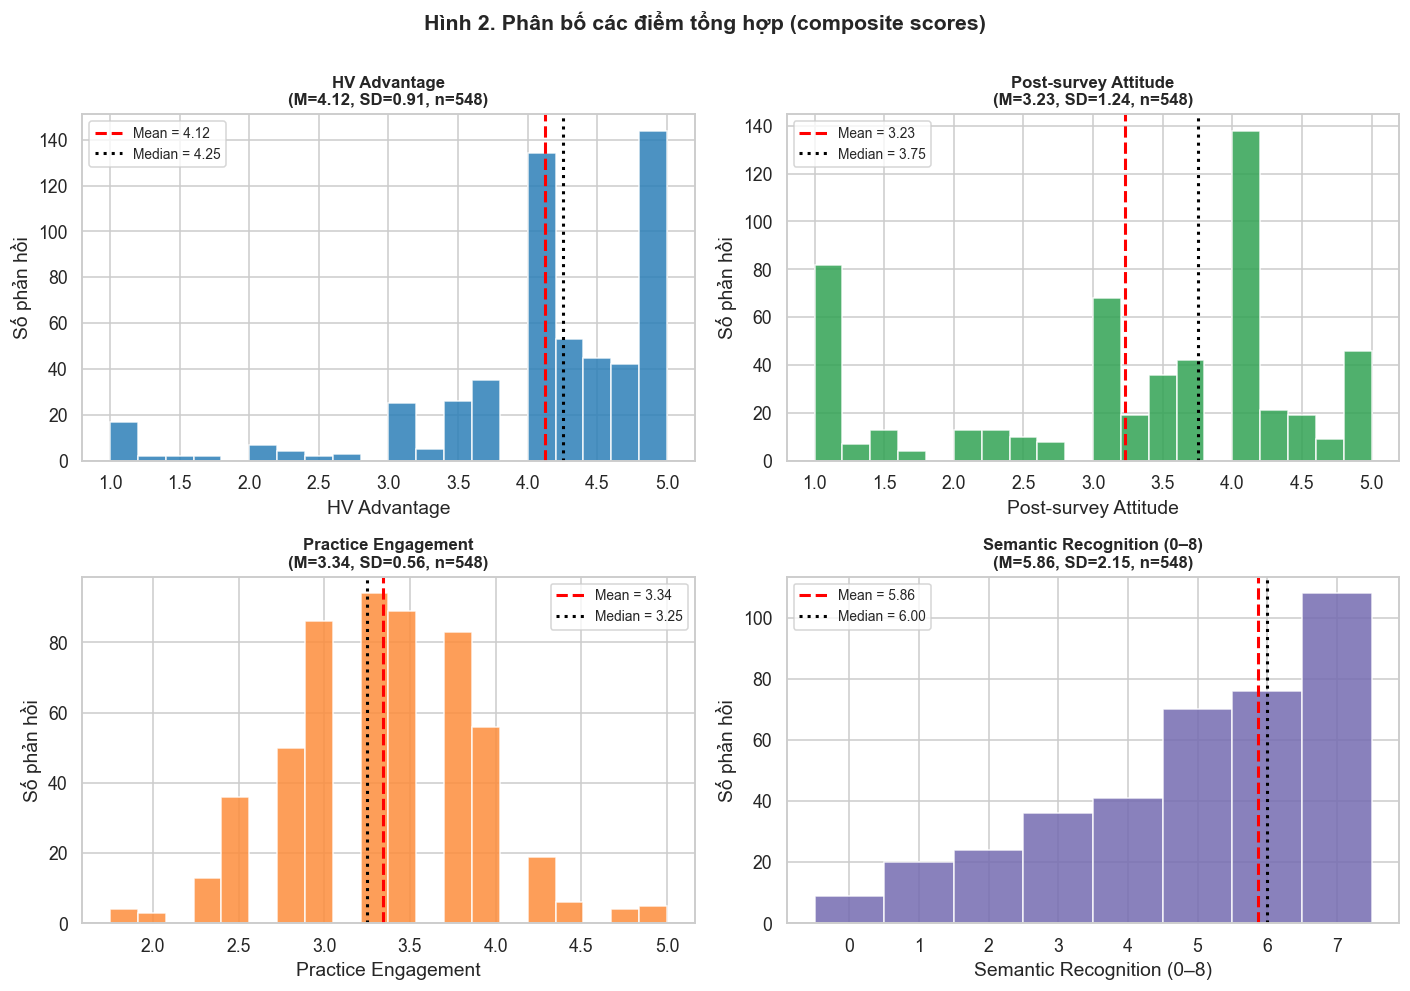

In [13]:
# Hình 2 — Phân bố 4 điểm tổng hợp
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

plot_info = [
    ('HV_score',       'HV Advantage', '#2c7fb8'),
    ('POST_score',     'Post-survey Attitude', '#31a354'),
    ('PRACTICE_score', 'Practice Engagement',  '#fd8d3c'),
    ('SEM_score',      'Semantic Recognition (0–8)', '#756bb1'),
]
for ax, (var, label, c) in zip(axes.flatten(), plot_info):
    data = df[var].dropna()
    bins = np.arange(0, 9) - 0.5 if var == 'SEM_score' else 20
    ax.hist(data, bins=bins, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean = {data.mean():.2f}')
    ax.axvline(data.median(), color='black', linestyle=':', linewidth=2,
               label=f'Median = {data.median():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Số phản hồi')
    ax.set_title(f'{label}\n(M={data.mean():.2f}, SD={data.std():.2f}, n={len(data)})',
                 fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Hình 2. Phân bố các điểm tổng hợp (composite scores)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('fig02_composite_distributions.png', dpi=300)
plt.show()

## 8. Biến kiểm tra kiến thức

### 8.1 Q10 — "Bạn có biết chữ Hán có khoảng bao nhiêu bộ thủ?"
Đáp án đúng: **214 bộ**

In [14]:
q10_dist = df['Q10'].value_counts(dropna=False)
print('Phân bố Q10:')
print(q10_dist.to_string())

correct_rate = df['Q10_correct'].mean()
print(f'\n→ Tỉ lệ biết đúng (214 bộ): {correct_rate*100:.1f}% ({df["Q10_correct"].sum()}/{len(df)})')

Phân bố Q10:
Q10
Khoảng 214 bộ           411
Không biết chính xác     89
Khoảng 100 bộ            22
Khoảng 50 bộ             20
Không biết                6

→ Tỉ lệ biết đúng (214 bộ): 75.0% (411/548)


### 8.2 Q11 — "Bạn đã học được khoảng bao nhiêu bộ thủ?" (tự đánh giá)

In [15]:
# Phân bố Q11 sau khi chuẩn hoá sang thang 1–4
q11_labels = {1: '<50 bộ (1)', 2: '~50 bộ (2)', 3: '~100–150 bộ (3)', 4: '214 bộ (4)'}
q11_dist = df['Q11_num'].value_counts(dropna=False).sort_index()
print('Phân bố Q11 (self-report, đã chuẩn hoá):')
for k, v in q11_dist.items():
    label = q11_labels.get(k, 'Không phân loại được') if pd.notna(k) else 'Missing'
    print(f'   {label:25s}: {v:4d} ({v/len(df)*100:.1f}%)')

Phân bố Q11 (self-report, đã chuẩn hoá):
   <50 bộ (1)               :   13 (2.4%)
   ~50 bộ (2)               :  271 (49.5%)
   ~100–150 bộ (3)          :  100 (18.2%)
   214 bộ (4)               :  154 (28.1%)
   Missing                  :   10 (1.8%)


## 9. Câu hỏi multi-select — số lựa chọn trung bình

Các câu `Q9, Q12, Q21, Q22, Q26, Q41, Q42, Q48` cho phép chọn **nhiều đáp án**. Mỗi câu được biến thành 2 cột phụ: `_list` (list lựa chọn) và `_n` (số lựa chọn).

In [16]:
print('Số lựa chọn trung bình mỗi câu multi-select:\n')
multi_summary = []
for col in MULTI_COLS:
    n_col = col + '_n'
    q_row = questions[questions['ID'] == col].iloc[0]
    q_text = q_row['Question'].split('.', 1)[1].strip()[:60] if '.' in q_row['Question'] else q_row['Question'][:60]
    multi_summary.append({
        'ID': col,
        'Section': q_row['Section'],
        'Nội dung (rút gọn)': q_text,
        'Mean': round(df[n_col].mean(), 2),
        'Max': df[n_col].max(),
    })
pd.DataFrame(multi_summary)

Số lựa chọn trung bình mỗi câu multi-select:



,ID,Section,Nội dung (rút gọn),Mean,Max
0,Q9,S2,"Theo bạn, bộ thủ giúp ích gì khi học chữ Hán? (Có thể chọn n",2.73,6
1,Q12,S2,Bạn thường gặp những khó khăn gì khi học bộ thủ? (Có thể chọ,1.68,4
2,Q21,S3,Những chữ như 林、森、众 khiến bạn liên tưởng đến: (có thể chọn n,2.06,5
3,Q22,S3,"Khi gặp chữ có cấu trúc lặp lại (chữ chồng chữ), bạn thường:",1.75,4
4,Q26,S3,"Theo bạn, cấu trúc chữ chồng chữ (như 森, 晶) tạo nên vẻ đẹp n",1.37,3
5,Q41,S4.3,"Khi bạn đoán sai nghĩa của chữ Hán, nguyên nhân thường là: (",1.94,5
6,Q42,S4.3,"Theo bạn, trong các yếu tố sau yếu tố nào giúp bạn tiến bộ n",2.28,5
7,Q48,S5,"Khi học tiếng Trung, bạn có mong muốn được hướng dẫn áp dụng",4.46,9


## 10. Các câu đoán nghĩa chữ chồng chữ (Q30–Q37)

Mỗi câu có 1 đáp án đúng dựa trên **"Thuyết văn giải tự"** (說文解字) và nghĩa truyền thống trong từ điển Khang Hy. Điểm `SEM_score` = tổng số câu trả lời đúng (0–8).

In [17]:
sem_rows = []
for qid, (char, name, correct) in CORRECT_ANSWERS.items():
    s = df[qid].dropna()
    n_correct = (s == correct).sum()
    sem_rows.append({
        'Câu': qid,
        'Chữ': char,
        'Âm Hán-Việt': name,
        'Đáp án đúng': correct[:45] + '…' if len(correct) > 45 else correct,
        'N': len(s),
        '% đúng': round(n_correct/len(s)*100, 1),
    })
sem_df = pd.DataFrame(sem_rows).sort_values('% đúng', ascending=False).reset_index(drop=True)
print('BẢNG 2. Tỉ lệ trả lời đúng từng câu Q30–Q37')
print('=' * 100)
print(sem_df.to_string(index=False))

print(f'\n→ SEM_score trung bình: {df["SEM_score"].mean():.2f}/8 ({df["SEM_pct"].mean():.1f}%)')
print(f'→ % người đúng ≥ 6/8 câu: {(df["SEM_score"] >= 6).mean()*100:.1f}%')
print(f'→ % người đúng toàn bộ 8/8: {(df["SEM_score"] == 8).mean()*100:.1f}%')

BẢNG 2. Tỉ lệ trả lời đúng từng câu Q30–Q37
Câu Chữ Âm Hán-Việt                                    Đáp án đúng   N  % đúng
Q30   淼        Miễu                      Biển nước rộng, mênh mông 548    81.8
Q37   囍      Hỉ kép         Niềm vui lớn gắn với sự kiện trọng đại 548    80.3
Q33   炎        Viêm                                       Lửa mạnh 548    79.9
Q34   品        Phẩm                Nhiều người cùng nói / đánh giá 548    74.8
Q31   休         Hưu                                      Nghỉ ngơi 548    72.6
Q35   众       Chúng                          Nhiều người, đám đông 548    71.9
Q36   双        Song Hai sự vật đi thành một đôi (vd: đôi giày, đô… 548    63.9
Q32   忍        Nhẫn                   Kiềm chế cảm xúc / chịu đựng 548    61.3

→ SEM_score trung bình: 5.86/8 (73.3%)
→ % người đúng ≥ 6/8 câu: 63.5%
→ % người đúng toàn bộ 8/8: 29.9%


## 11. Tóm tắt EDA

Các điểm chính cần ghi nhớ trước khi đi vào phân tích sâu:

1. **Mẫu N = 548** — đủ lớn cho phân tích đa biến (EFA, Ordinal Logit, SEM).
2. **Phân bố trình độ HSK lệch về phía đầu**: 62% là Mới bắt đầu + HSK1–2, phản ánh đúng quần thể người Việt học tiếng Trung (đa số là người mới học).
3. **32 biến Likert đã mã hoá** sang thang số, bao gồm 2 reverse-coded (Q13_5, Q50_5).
4. **4 điểm tổng hợp** được tính: HV_score, POST_score, PRACTICE_score, SEM_score.
5. **Điểm nhận diện nghĩa SEM ≈ 5.86/8** — khá cao, cho thấy người học có khả năng suy luận từ cấu trúc.
6. **Q32 (忍 nhẫn)** và **Q36 (双 song)** là khó nhất — đây là insight quan trọng cho phân tích nâng cao (IRT).

---

### → Tiếp theo:
- **Notebook 02** — Phân tích định lượng (Cronbach's α, Chi-square, Kruskal-Wallis, effect sizes, FDR)
- **Notebook 03** — Phân tích định tính (multi-select, thematic coding, word cloud, co-occurrence network)
- **Notebook 04** — Phân tích nâng cao (EFA, Ordinal Logit, CA, K-modes Cluster, IRT)

In [18]:
# Lưu df đã xử lý sang parquet để các notebook sau đọc lại nhanh hơn
df.to_parquet('df_clean.parquet')
questions.to_parquet('questions.parquet')
sections.to_parquet('sections.parquet')
print('✅ Saved: df_clean.parquet, questions.parquet, sections.parquet')
print(f'   → {len(df)} rows × {df.shape[1]} cols')

✅ Saved: df_clean.parquet, questions.parquet, sections.parquet
   → 548 rows × 122 cols
